In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel, VoigtModel, ConstantModel
from scipy.special import wofz
from pathlib import Path
from scipy.ndimage import median_filter
from scipy.signal import find_peaks

<h3 style="color: #e19edc;"> Lectura de espectros del 2018</h3>

In [2]:
#Rutas Julio, Agosto y Septiembre

ruta_24_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-07-24.xlsx"
ruta_27_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-07-27.xlsx"
ruta_03_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-03.xlsx"
ruta_07_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-07.xlsx"
ruta_11_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-11.xlsx"
ruta_16_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-16.xlsx"
ruta_23_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-23.xlsx"
ruta_29_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-29.xlsx"
ruta_11_septiembre = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-09-11.xlsx"

In [3]:
#Datos de Julio, Agosto y Septiembre

antares_24_julio = pd.read_excel(ruta_24_julio, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_27_julio = pd.read_excel(ruta_27_julio, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_03_agosto = pd.read_excel(ruta_03_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_07_agosto = pd.read_excel(ruta_07_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_11_agosto = pd.read_excel(ruta_11_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_16_agosto = pd.read_excel(ruta_16_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_23_agosto = pd.read_excel(ruta_23_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_29_agosto = pd.read_excel(ruta_29_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_11_septiembre = pd.read_excel(ruta_11_septiembre, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])

In [4]:
espectros = {
    "antares_24_julio": antares_24_julio,
    "antares_27_julio": antares_27_julio,
    "antares_03_agosto": antares_03_agosto,
    "antares_07_agosto": antares_07_agosto,
    "antares_11_agosto": antares_11_agosto,
    "antares_16_agosto": antares_16_agosto,
    "antares_23_agosto": antares_23_agosto,
    "antares_29_agosto": antares_29_agosto,
    "antares_11_septiembre": antares_11_septiembre,
}

<h4 style="color: #e19edc;"> Parámetros de la normalización con el método Sigma - Clipping</h4>

In [5]:
guardar_graficos = True   
carpeta_graficos = "./Graficas 2018/Espectros_normalizados"  
 
col_longitud_onda = "Longitud onda"
col_flujo = "Flujo"
 
grado_polinomio= 2     
N_iteraciones = 10
sigma_corte = 2.0

<h5 style="color: #e19edc;"> Modelo</h5>

In [6]:
def ajustar_continuo(longitud_onda, flujo, grado, n_iter, sigma):

    longitud_onda = np.asarray(longitud_onda, dtype=float)
    flujo = np.asarray(flujo, dtype=float)
 
    mascara = np.ones_like(flujo, dtype=bool)
 
    for _ in range(n_iter):
        coef = np.polyfit(longitud_onda[mascara], flujo[mascara], deg=grado)
        continuo_iter = np.polyval(coef, longitud_onda)
 
        residuo = flujo - continuo_iter
        
        mediana = np.median(residuo[mascara])
        mad = np.median(np.abs(residuo[mascara] - mediana))
        mad_std = mad * 1.4826

        umbral_superior = mediana + sigma * mad_std
        umbral_inferior = mediana - sigma * mad_std
        nueva_mascara = (residuo > umbral_inferior) & (residuo < umbral_superior)
 
        if nueva_mascara.sum() < grado + 2:
            break

        if np.array_equal(nueva_mascara, mascara):
            break
 
        mascara = nueva_mascara
 
    coef_final = np.polyfit(longitud_onda[mascara], flujo[mascara], deg=grado)
    continuo = np.polyval(coef_final, longitud_onda)
 
    return continuo, mascara


<h5 style="color: #e19edc;"> Verificación del modelo con gráficos</h5>


Procesando: antares_24_julio
  Puntos totales: 203
  Puntos excluidos: 51
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_24_julio_control.png


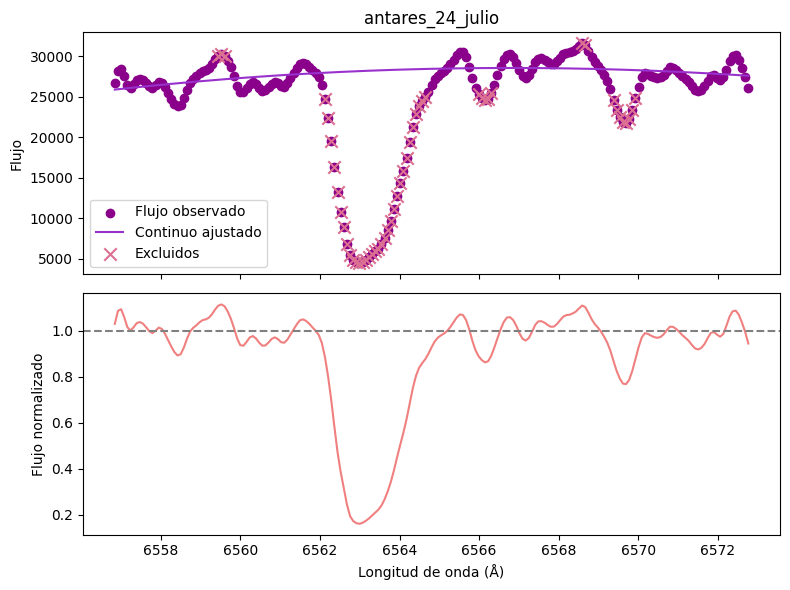


Procesando: antares_27_julio
  Puntos totales: 158
  Puntos excluidos: 68
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_27_julio_control.png


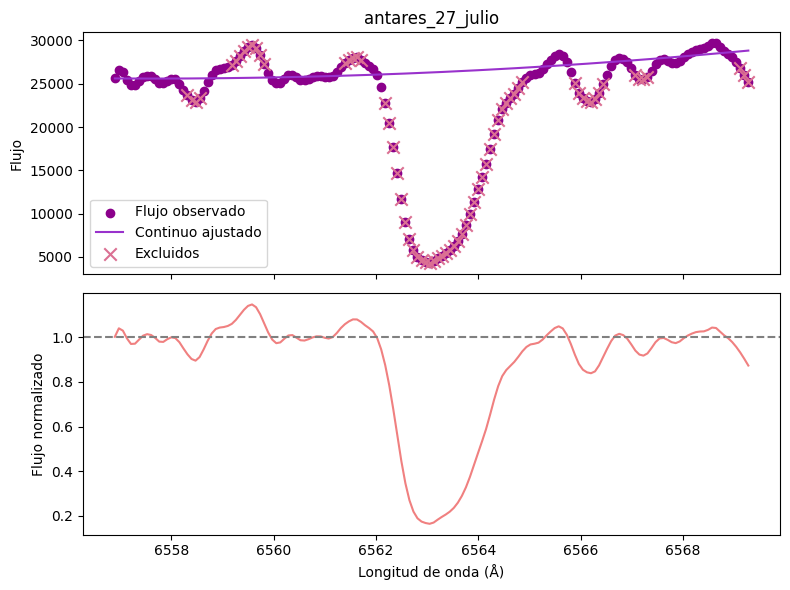


Procesando: antares_03_agosto
  Puntos totales: 161
  Puntos excluidos: 44
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_03_agosto_control.png


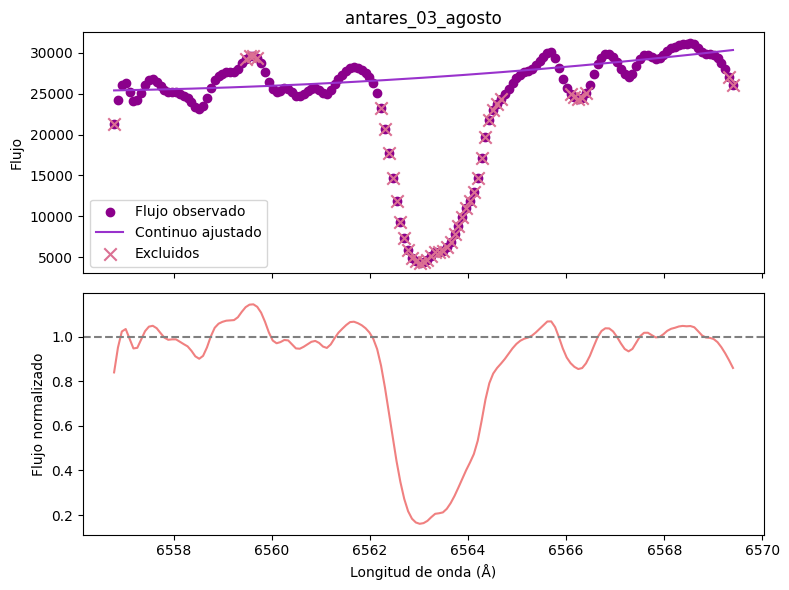


Procesando: antares_07_agosto
  Puntos totales: 162
  Puntos excluidos: 54
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_07_agosto_control.png


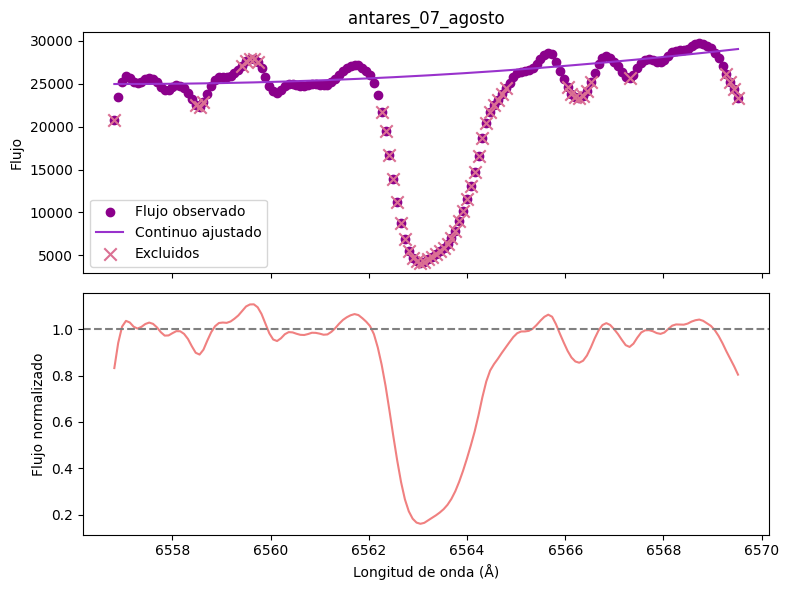


Procesando: antares_11_agosto
  Puntos totales: 163
  Puntos excluidos: 62
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_11_agosto_control.png


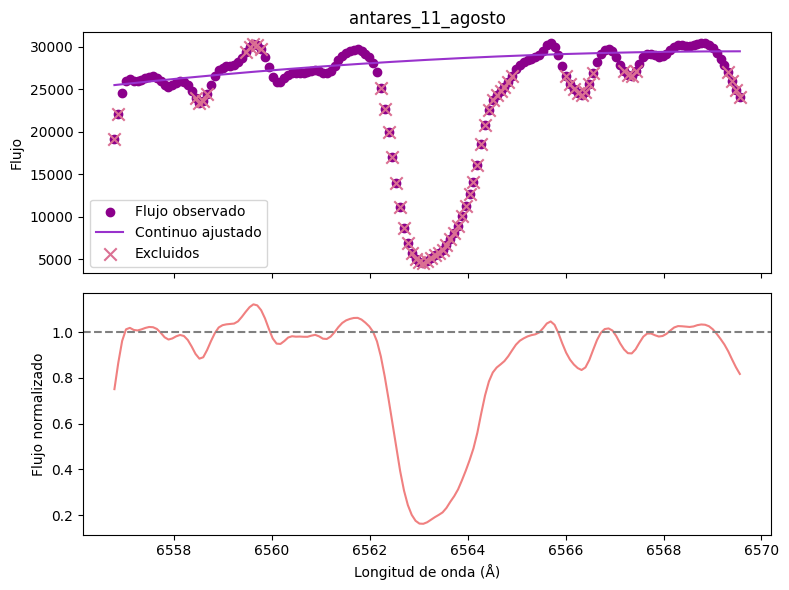


Procesando: antares_16_agosto
  Puntos totales: 163
  Puntos excluidos: 61
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_16_agosto_control.png


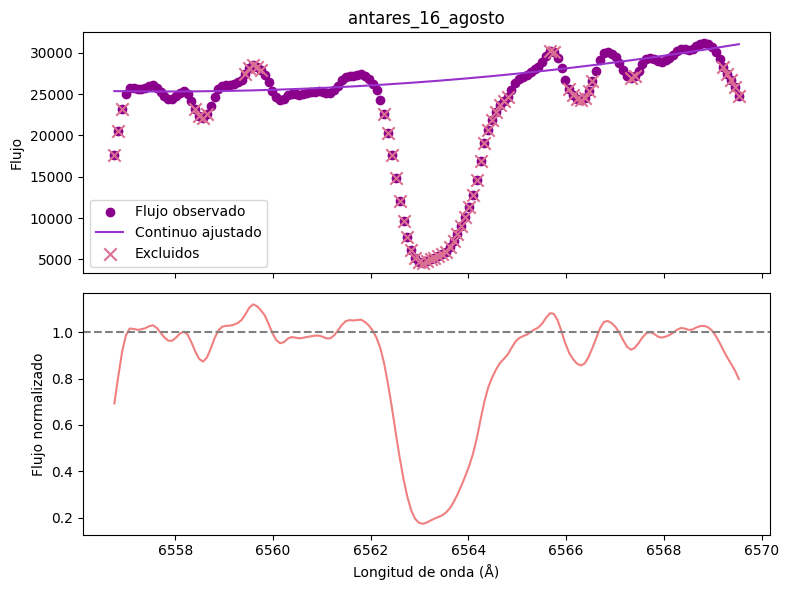


Procesando: antares_23_agosto
  Puntos totales: 162
  Puntos excluidos: 52
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_23_agosto_control.png


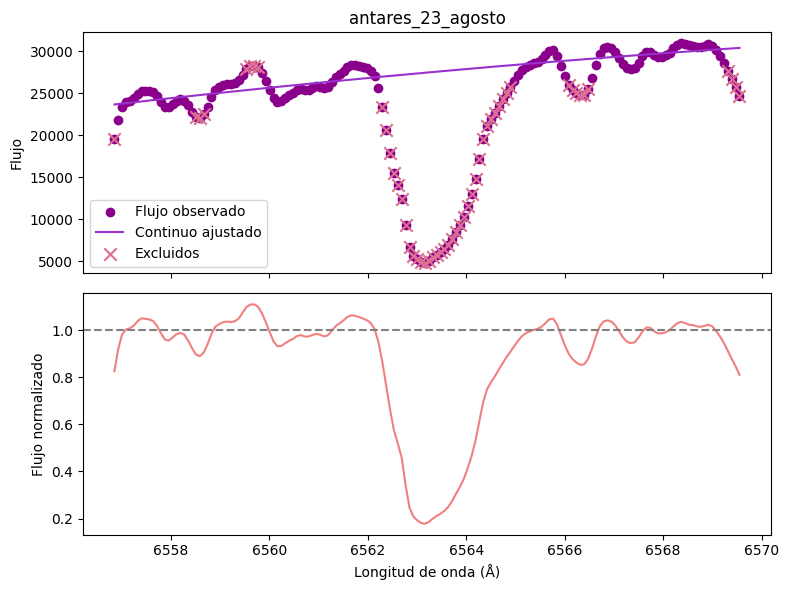


Procesando: antares_29_agosto
  Puntos totales: 206
  Puntos excluidos: 83
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_29_agosto_control.png


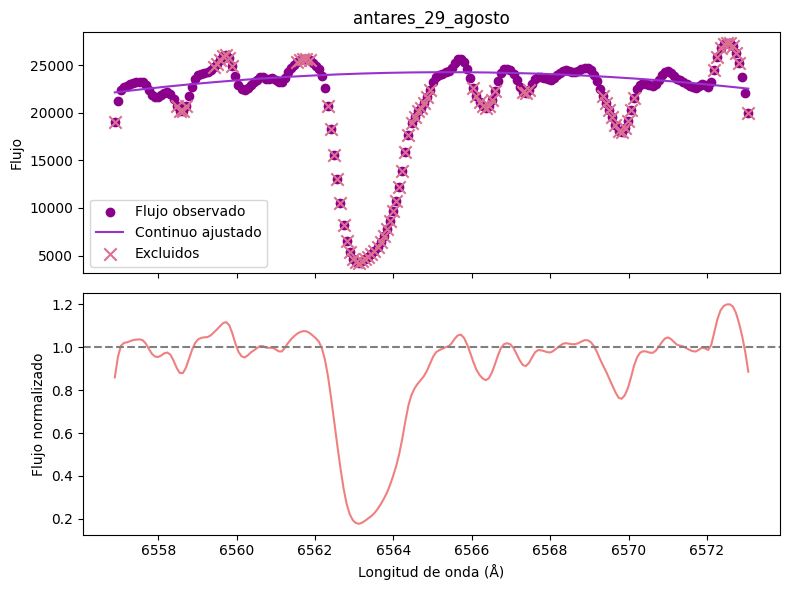


Procesando: antares_11_septiembre
  Puntos totales: 208
  Puntos excluidos: 64
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_11_septiembre_control.png


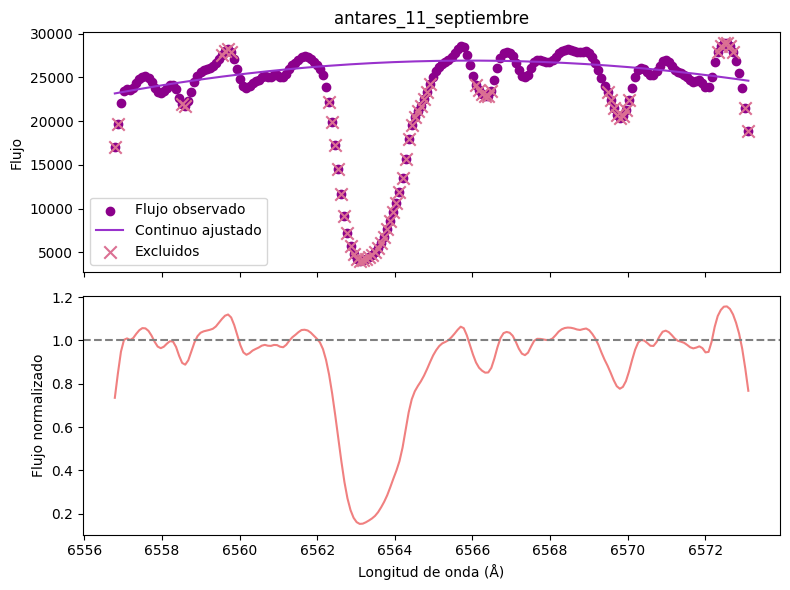


Proceso completo.


In [7]:
if guardar_graficos:
    Path(carpeta_graficos).mkdir(exist_ok=True)
 
for nombre, df in espectros.items():
    print(f"\nProcesando: {nombre}")
 
    longitud_onda = df[col_longitud_onda].values
    flujo = df[col_flujo].values
 
    continuo, mascara_continuo = ajustar_continuo(longitud_onda, flujo, grado_polinomio, N_iteraciones, sigma_corte)

    df["Continuo ajustado"] = continuo
    df["Flujo normalizado"] = flujo / continuo
    df["Usado en ajuste"] = mascara_continuo

    print(f"  Puntos totales: {len(mascara_continuo)}")
    print(f"  Puntos excluidos: {(~mascara_continuo).sum()}")

    mascara_bool = np.asarray(mascara_continuo, dtype=bool)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
 
    ax1.scatter(longitud_onda, flujo, color = "darkmagenta", label="Flujo observado")
    ax1.plot(longitud_onda, continuo, color ="darkorchid", label="Continuo ajustado")
    ax1.scatter(longitud_onda[~mascara_bool], flujo[~mascara_bool], color = "palevioletred",marker = "x", label="Excluidos", s = 80)
    ax1.set_ylabel("Flujo")
    ax1.legend()
    ax1.set_title(nombre)
 
    ax2.plot(longitud_onda, df["Flujo normalizado"], color ="lightcoral")
    ax2.axhline(1.0, color="gray", linestyle="--")
    ax2.set_ylabel("Flujo normalizado")
    ax2.set_xlabel("Longitud de onda (Å)")
 
    plt.tight_layout()
 
    if guardar_graficos:
        fig_path = Path(carpeta_graficos) / f"{nombre}_control.png"
        plt.savefig(fig_path, dpi=120)
        print(f"  -> Gráfico guardado: {fig_path}")
 
    plt.show()
    plt.close(fig)
 
print("\nProceso completo.")

<h3 style="color: #e19edc;"> Obtención del perfil de absorción y emisión de la línea H<sub>&alpha;</sub></h3>

<h4 style="color: #e19edc;"> Teniendo en cuenta las posibles mezclas con las líneas de absorción</h4>

<h5 style="color: #e19edc;"> Funciones complementarias</h5>

In [8]:
c_kms_s = 299792.458

def efecto_doppler(longitud_lab, velocidad_kms):
    return longitud_lab * (1 + velocidad_kms / c_kms_s)

def velocidad_desde_doppler(longitud_lab, longitud_obs):
    return c_kms_s * (longitud_obs / longitud_lab - 1)

def profundidad_interpolada(teff, t_ref=(3500, 4250), prof_ref=(0.55, 0.63)):
    return float(np.interp(teff, t_ref, prof_ref))

def amplitud_desde_profundidad(profundidad, continuo_local, sigma, gamma):
    z = 1j * gamma / (sigma * np.sqrt(2))
    pico_unitario = wofz(z).real / (sigma * np.sqrt(2 * np.pi))
    return -profundidad * continuo_local / pico_unitario

In [9]:
def velocidad_desde_centro_libre(fit, nombre_linea, centro_lab):
    centro_obs = fit.params[f"{nombre_linea}_center"].value
    centro_obs_err = fit.params[f"{nombre_linea}_center"].stderr
    v = velocidad_desde_doppler(centro_lab, centro_obs)
    v_err = c_kms_s * centro_obs_err / centro_lab if centro_obs_err is not None else None
    return v, v_err


def comparar_velocidades(v_ajustada, v_ajustada_err, velocidades_referencia, nombres_referencia=None):

    if nombres_referencia is None:
        nombres_referencia = [f"Referencia {i+1}" for i in range(len(velocidades_referencia))]

    texto_v = f"{v_ajustada:.2f}" + (f" ± {v_ajustada_err:.2f}" if v_ajustada_err else "")
    print(f"Velocidad óptima (ajuste, centro libre): {texto_v} km/s")

    for nombre, v_ref in zip(nombres_referencia, velocidades_referencia):
        diff = v_ajustada - v_ref
        print(f"  vs {nombre} = {v_ref:.2f} km/s  ->  Δv = {diff:+.2f} km/s")

In [10]:
def estimar_continuo_local(longitud_onda, flujo, centro_aprox, semiancho_exclusion=4.0, sigma=2.0, n_iter=10):
    fuera_de_linea = np.abs(longitud_onda - centro_aprox) > semiancho_exclusion
    valores = flujo[fuera_de_linea]

    mascara = np.ones_like(valores, dtype=bool)
    for _ in range(n_iter):
        mediana = np.median(valores[mascara])
        mad = np.median(np.abs(valores[mascara] - mediana)) * 1.4826
        nueva_mascara = np.abs(valores - mediana) < sigma * mad
        if nueva_mascara.sum() < 5:
            break
        mascara = nueva_mascara

    return float(np.median(valores[mascara]))

In [11]:
def estimar_ancho_inicial_metalica(longitud_onda, flujo, continuo_local, centro_obs, ventana=0.5, sigma_default=0.12, gamma_default=0.05):

    mask = np.abs(longitud_onda - centro_obs) < ventana
    if mask.sum() < 4:
        return sigma_default, gamma_default

    x_local = longitud_onda[mask]
    y_local = flujo[mask]

    prof_local = continuo_local - y_local.min()
    if prof_local <= 0:
        return sigma_default, gamma_default

    nivel_media_altura = continuo_local - prof_local / 2

    por_debajo = y_local < nivel_media_altura
    if por_debajo.sum() < 2:
        return sigma_default, gamma_default

    x_cruce = x_local[por_debajo]
    fwhm_est = x_cruce.max() - x_cruce.min()

    if fwhm_est <= 0:
        return sigma_default, gamma_default

    sigma_inicial = max(0.02, fwhm_est / 2.355)
    gamma_inicial = max(0.0, fwhm_est * 0.15)

    return sigma_inicial, gamma_inicial

<h5 style="color: #e19edc;"> Modelamiento </h5>

In [18]:
#MODELO DE AJUSTE

def construccion_del_modelo(lineas_metalicas=None):
    continuo = ConstantModel(prefix="cont_")
    em_azul = VoigtModel(prefix="em_azul_")
    valle_abs = VoigtModel(prefix="valle_abs_")
    modelo = continuo + em_azul + valle_abs

    if lineas_metalicas:
        for linea in lineas_metalicas:
            modelo += VoigtModel(prefix=f"{linea['nombre']}_")

    return modelo

def encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox, lineas_metalicas, teff=3660):
    p = modelo.make_params()

    # Continuo
    continuo_local = estimar_continuo_local(longitud_onda, flujo, centro_aprox)
    p["cont_c"].set(value=continuo_local, min=continuo_local - 0.05, max=continuo_local + 0.05)

    flujo_suave = median_filter(flujo, size = 5)

    # Emisión Azul

    izquierda = (longitud_onda < (centro_aprox - 0.25)) & (longitud_onda > (centro_aprox - 2.5))

    if np.any(izquierda):
        x_izq = longitud_onda[izquierda]
        y_izq = flujo_suave[izquierda]

        picos, props = find_peaks(y_izq, prominence=0.01)

        if len(picos) > 0:
            idx_mejor = picos[np.argmax(props["prominences"])]
            c_azul_inicio = x_izq[idx_mejor]
            amp_azul_inicio = max(0.05, flujo[izquierda][idx_mejor] - continuo_local)
        else:
            i_azul = np.argmax(y_izq)
            c_azul_inicio = x_izq[i_azul]
            amp_azul_inicio = max(0.05, flujo[izquierda][i_azul] - continuo_local)
    else:
        c_azul_inicio = centro_aprox - 0.8
        amp_azul_inicio = 0.2

    p["em_azul_center"].set(value = c_azul_inicio, min = centro_aprox - 2.8, max = centro_aprox - 0.15)
    p["em_azul_amplitude"].set(value = amp_azul_inicio * 0.5, min = 0, max = amp_azul_inicio * 5.0)
    p["em_azul_sigma"].set(value = 0.30, min = 0.05, max = 1.2)
    p["em_azul_gamma"].set(value = 0.15, min = 0.0, max = 1.0, vary=True)

    # Absorción central (Halpha)

    ventana_centro = np.abs(longitud_onda - centro_aprox) < 1.8

    if np.any(ventana_centro):
        idx_local = np.argmin(flujo_suave[ventana_centro])
        c_abs_inicio = longitud_onda[ventana_centro][idx_local]
    else:
        c_abs_inicio = centro_aprox

    i_min = np.argmin(np.abs(longitud_onda - c_abs_inicio))

    p["valle_abs_center"].set(value = c_abs_inicio, min = centro_aprox - 1.0, max = centro_aprox + 1.0)

    prof_abs_est = max(0.1, continuo_local - flujo[i_min])
    amp_abs_inicio = -prof_abs_est * 0.8
    p["valle_abs_amplitude"].set(value = amp_abs_inicio, max = 0)
    p["valle_abs_sigma"].set(value = 0.25, min = 0.05, max = 1.0)
    p["valle_abs_gamma"].set(value = 0.15, min = 0, max = 0.8, vary=True)

    # Líneas Metálicas
    if lineas_metalicas:
        for linea in lineas_metalicas:
            pref = f"{linea['nombre']}_"
            c0_lab = linea["centro"]

            if linea.get("centro_libre", False):
                margen_v = linea.get("margen_v_libre", 25.0)
                margen_aa = c0_lab * margen_v / c_kms_s
                v_referencia = linea.get("velocidad_referencia", 0.0)
                valor_inicial = linea.get("centro_inicial", efecto_doppler(c0_lab, v_referencia))
                p[f"{pref}center"].set(value=valor_inicial,
                                        min=valor_inicial - margen_aa,
                                        max=valor_inicial + margen_aa)
                c0_obs = valor_inicial 
            else:
                v = linea.get("velocidad", 0.0)
                c0_obs = efecto_doppler(c0_lab, v)
                margen_v = linea.get("incertidumbre_v", 3.0)
                margen_aa = c0_lab * margen_v / c_kms_s
                p[f"{pref}center"].set(value=c0_obs, min=c0_obs - margen_aa, max=c0_obs + margen_aa)

            # Estimación del ancho de la línea
            sigma0_dato, gamma0_dato = estimar_ancho_inicial_metalica(longitud_onda, flujo, continuo_local, c0_obs)

            sigma0 = linea.get("sigma_inicial", sigma0_dato)
            gamma0 = linea.get("gamma_inicial", gamma0_dato)

            p[f"{pref}sigma"].set(value=sigma0, min=0.02, max=0.4)
            p[f"{pref}gamma"].set(value=gamma0, min=0, max=0.3, vary=True)

            prof = linea.get("profundidad")
            if prof is None:
                prof = profundidad_interpolada(
                    teff, t_ref=linea.get("t_ref", (3500, 4250)), prof_ref=linea.get("prof_ref", (0.55, 0.63)),
                )
                
            amp0 = amplitud_desde_profundidad(prof, continuo_local, sigma0, gamma0)

            profundidad_minima = 0.015
            amp_maxima = -profundidad_minima * continuo_local
            p[f"{pref}amplitude"].set(value=amp0, min=amp0 * 3.0, max=amp_maxima)

    return p

In [13]:
# DESCOMPOSICIÓN DE "PERFILES"

def fit_y_decomposicion(datos_cercanos, centro_aprox, longitud_observada, flujo_normalizado,
                         lineas_metalicas=None, teff=3660):
    longitud_onda = datos_cercanos[longitud_observada].to_numpy()
    flujo = datos_cercanos[flujo_normalizado].to_numpy()

    modelo = construccion_del_modelo(lineas_metalicas)
    parametros = encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox,
                                       lineas_metalicas, teff=teff)
    fit = modelo.fit(flujo, parametros, x=longitud_onda)

    comps = fit.eval_components(x=longitud_onda)
    continuo = comps["cont_"]

    perfil_emision = continuo + comps["em_azul_"]
    perfil_absorcion = continuo + comps["valle_abs_"]
    residuo = flujo - fit.best_fit

    return dict(longitud_onda = longitud_onda, flujo = flujo, fit = fit, comps = comps, perfil_emision = perfil_emision,
                perfil_absorcion = perfil_absorcion, residuo=residuo)

In [14]:
# VISUALIZACIÓN

def visualizacion_con_metalica(res_metal, lineas_metalicas, mes, titulo,):
    longitud_onda, flujo, fit = res_metal["longitud_onda"], res_metal["flujo"], res_metal["fit"]
    comps = res_metal["comps"]
    continuo = comps["cont_"]

    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                              gridspec_kw={"height_ratios": [2.2, 1]})

    ax = axes[0]
    ax.scatter(longitud_onda, flujo, s=18, color="darkcyan", label="Observado", zorder=3)
    ax.plot(longitud_onda, fit.best_fit, color="lightseagreen", lw=1.8, label="Modelo total")
    ax.plot(longitud_onda, res_metal["perfil_emision"], "--", color="turquoise", lw=1.3,
            label="Perfil de emisión")
    ax.plot(longitud_onda, res_metal["perfil_absorcion"], "--", color="deepskyblue", lw=1.3,
            label=r"Perfil de absorción $H_\alpha$")

    for linea in lineas_metalicas:
        pref = f"{linea['nombre']}_"
        perfil_metal = continuo + comps[pref]
        ax.plot(longitud_onda, perfil_metal, "-.", color="purple", lw=0.7,
                label=f"Componente {linea['nombre']}")
        ax.axvline(fit.params[f"{pref}center"].value, color="orchid",
                   lw=2.5, ls=":", alpha=0.7)

    ax.axhline(continuo[0], color="gray", lw=0.7, ls=":")
    ax.set_ylabel("Flujo normalizado")
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax2 = axes[1]
    ax2.plot(longitud_onda, res_metal["residuo"], color="black", lw=1)
    ax2.axhline(0, color="gray", lw=0.7)
    ax2.set_xlabel("Longitud de onda [Å]")
    ax2.set_ylabel("Residuo")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(fr"Graficas 2018\Modelamiento\halpha_{mes.lower()}_cobalto.png", dpi=150)
    plt.show()

In [19]:
def velocidad_y_error_combinados(meta):

    fuentes = []
    if meta.get("velocidad_visible") is not None:
        fuentes.append((meta["velocidad_visible"], meta.get("incertidumbre_v_visible", 1.0)))
    if meta.get("velocidad_infrarrojo") is not None:
        fuentes.append((meta["velocidad_infrarrojo"], meta.get("incertidumbre_v_infrarrojo", 1.0)))

    if not fuentes:
        return None, None
    if len(fuentes) == 1:
        return fuentes[0]

    pesos = [1 / (err ** 2) for _, err in fuentes]
    v_comb = sum(v * w for (v, _), w in zip(fuentes, pesos)) / sum(pesos)
    err_comb = np.sqrt(1 / sum(pesos))
    return v_comb, err_comb

In [20]:
centro_lab_cobalto = 6563.397

metadatos = {
    "antares_24_julio": {
        "fecha": "Julio 24-2018",
        "centro_aprox": 6562.994,
        "velocidad_visible": 19.4,
        "incertidumbre_v_visible": 0.7,
        "velocidad_infrarrojo": 19.76,
        "incertidumbre_v_infrarrojo": 0.05,
    },
    "antares_27_julio": {
        "fecha": "Julio 27-2018",
        "centro_aprox": 6563.045,
        "velocidad_visible": 20.2,
        "incertidumbre_v_visible": 0.8,
    },
    "antares_03_agosto": {
        "fecha": "Agosto 03-2018",
        "centro_aprox": 6563.015,
        "velocidad_visible": 23,
        "incertidumbre_v_visible": 0.9,
        "velocidad_infrarrojo": 23.5,
        "incertidumbre_v_infrarrojo": 0.03,
    },
    "antares_07_agosto": {
        "fecha": "Agosto 07-2018",
        "centro_aprox": 6563.05116,
        "velocidad_visible": 23.9,
        "incertidumbre_v_visible": 0.5,
        "velocidad_infrarrojo": 24.1,
        "incertidumbre_v_infrarrojo": 0.04,
    },
    "antares_11_agosto": {
        "fecha": "Agosto 11-2018",
        "centro_aprox": 6563.091,
        "velocidad_visible": 24.9,
        "incertidumbre_v_visible": 0.7,
    },
    "antares_16_agosto": {
        "fecha": "Agosto 16-2018",
        "centro_aprox": 6563.067,
        "velocidad_visible": 25.1,
        "incertidumbre_v_visible": 0.4,
        "velocidad_infrarrojo": 25.8,
        "incertidumbre_v_infrarrojo": 0.06,
    },
    "antares_23_agosto": {
        "fecha": "Agosto 23-2018",
        "centro_aprox": 6563.164,
        "velocidad_visible": 26,
        "incertidumbre_v_visible": 0.5,
        "velocidad_infrarrojo": 26.18,
        "incertidumbre_v_infrarrojo": 0.11,
    },
    "antares_29_agosto": {
        "fecha": "Agosto 29-2018",
        "centro_aprox": 6563.131,
        "velocidad_visible": 26.3,
        "incertidumbre_v_visible": 0.4,
        "velocidad_infrarrojo": 27.09,
        "incertidumbre_v_infrarrojo": 0.15,
    },
    "antares_11_septiembre": {
        "fecha": "Septiembre 11-2018",
        "centro_aprox": 6563.095,
        "velocidad_visible": 26,
        "incertidumbre_v_visible": 0.5,
        "velocidad_infrarrojo": 26.75,
        "incertidumbre_v_infrarrojo": 0.09,
    },
}

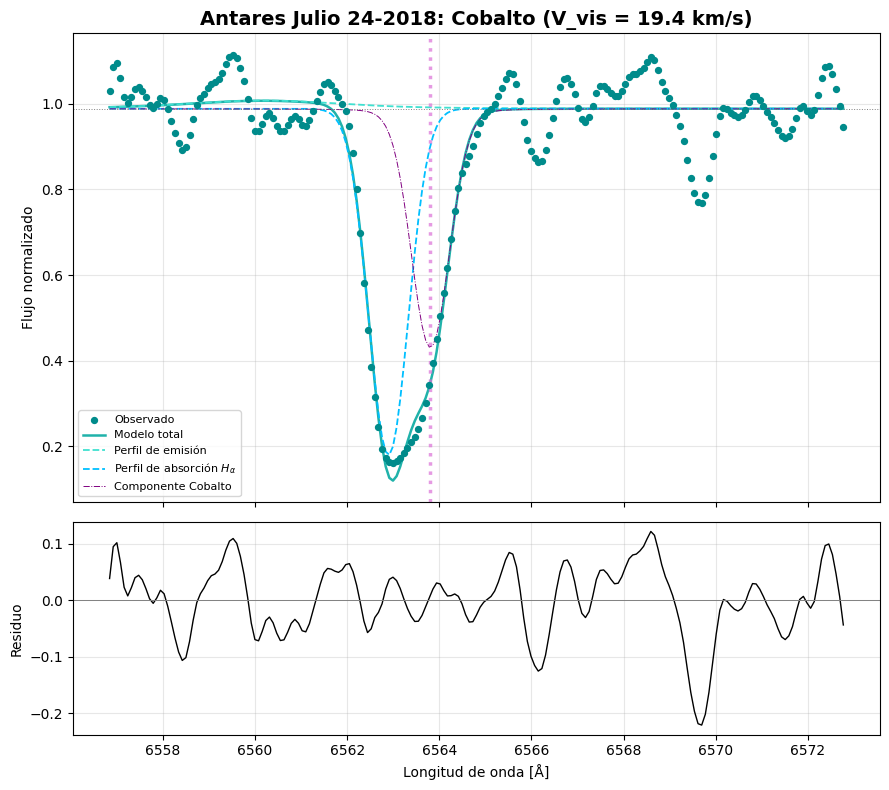

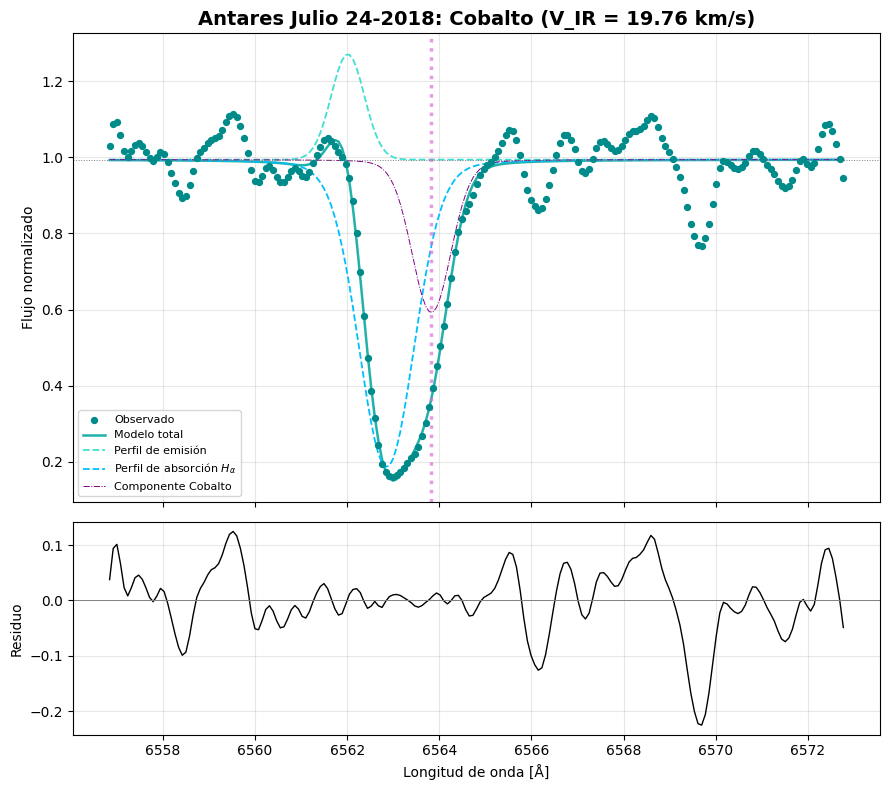

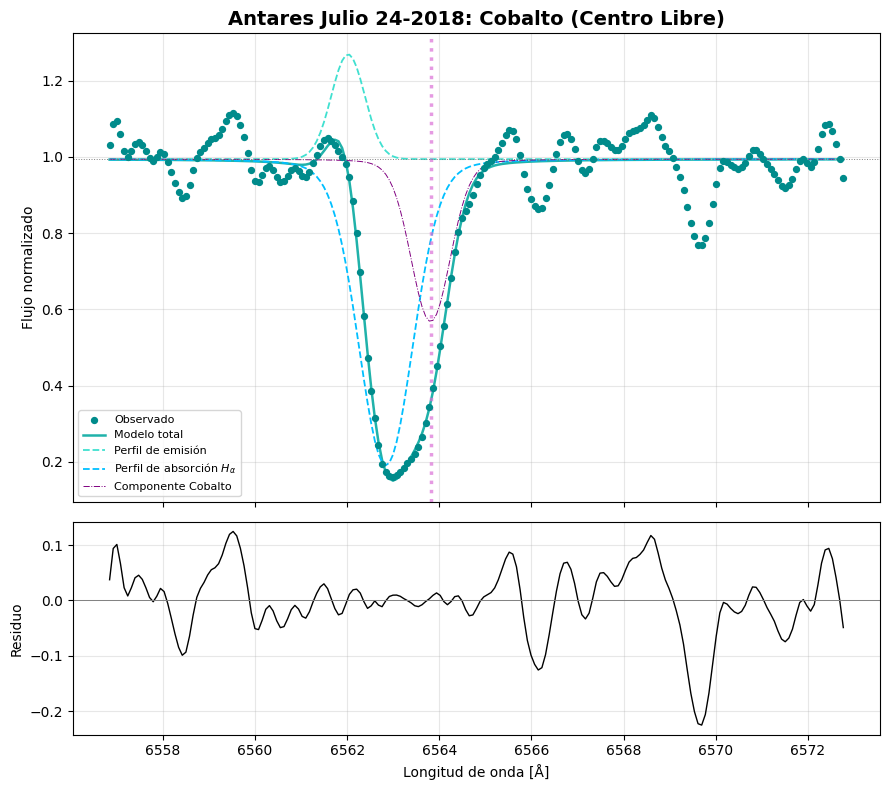

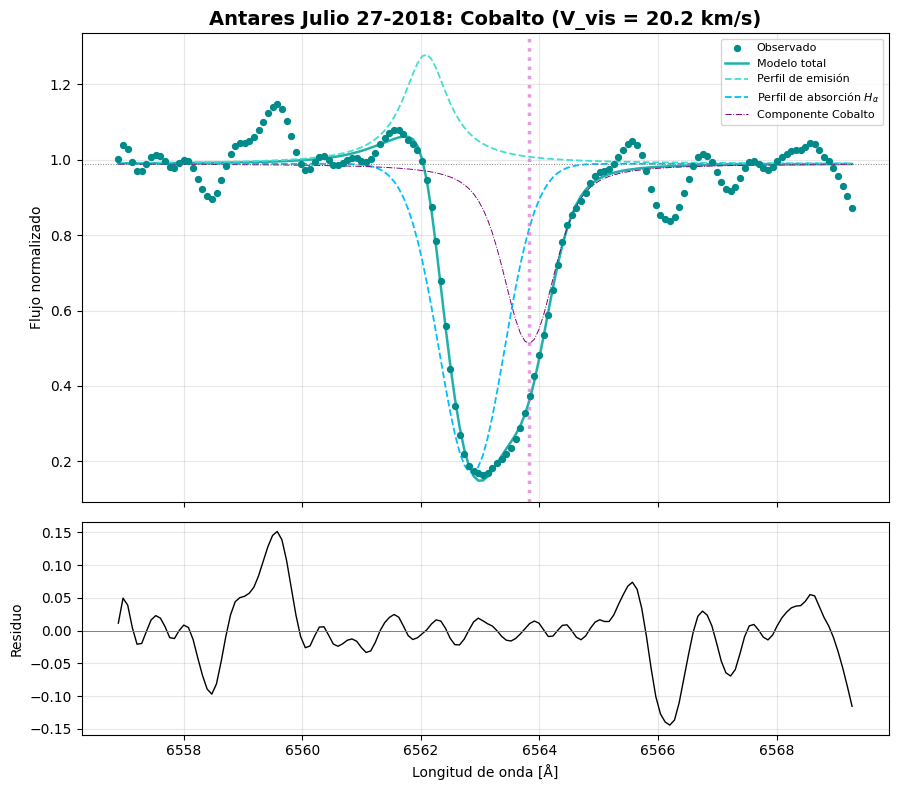

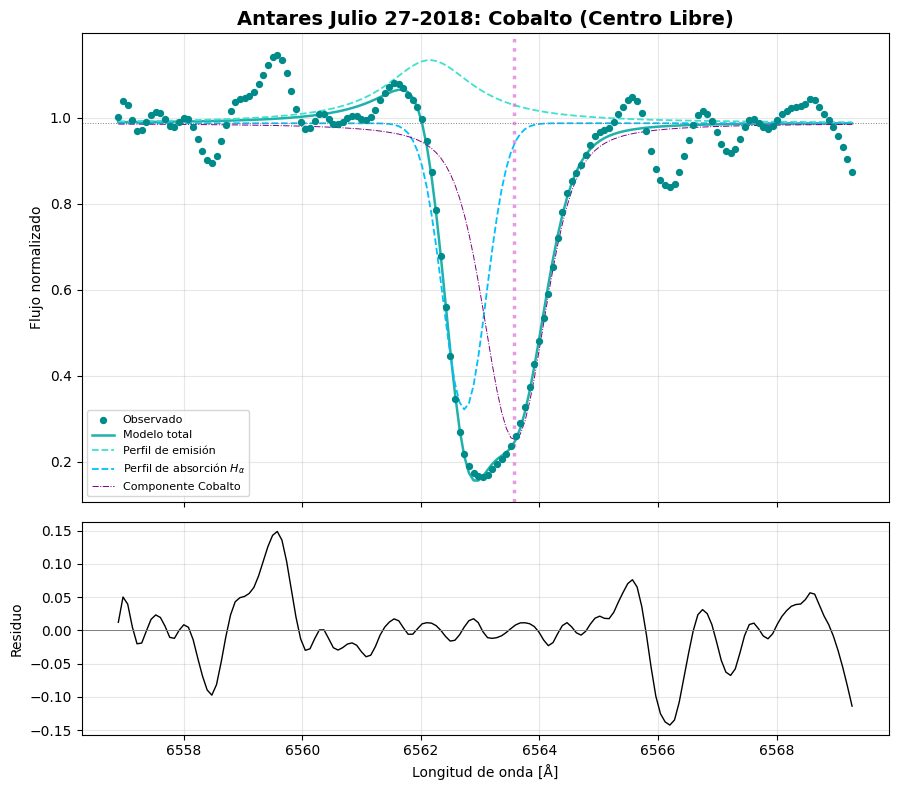

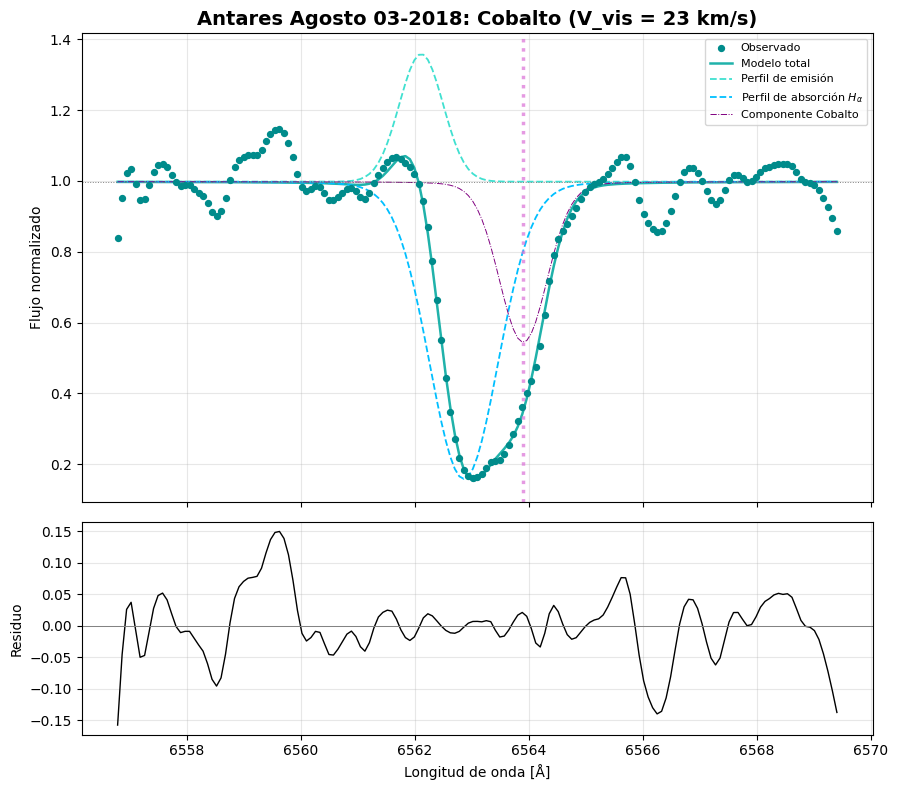

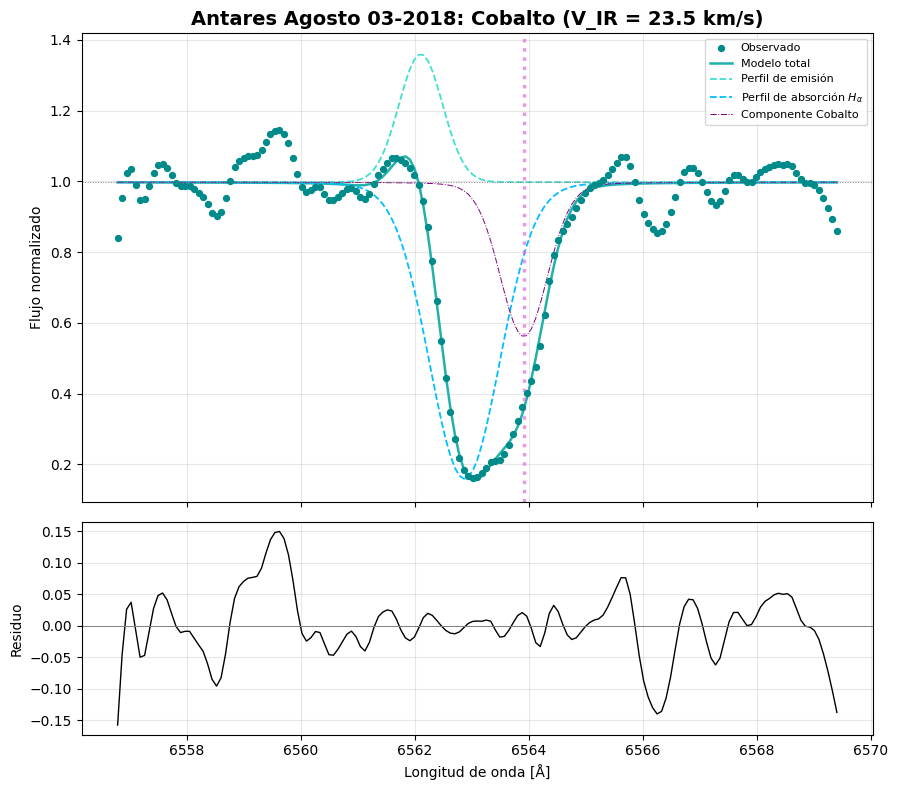

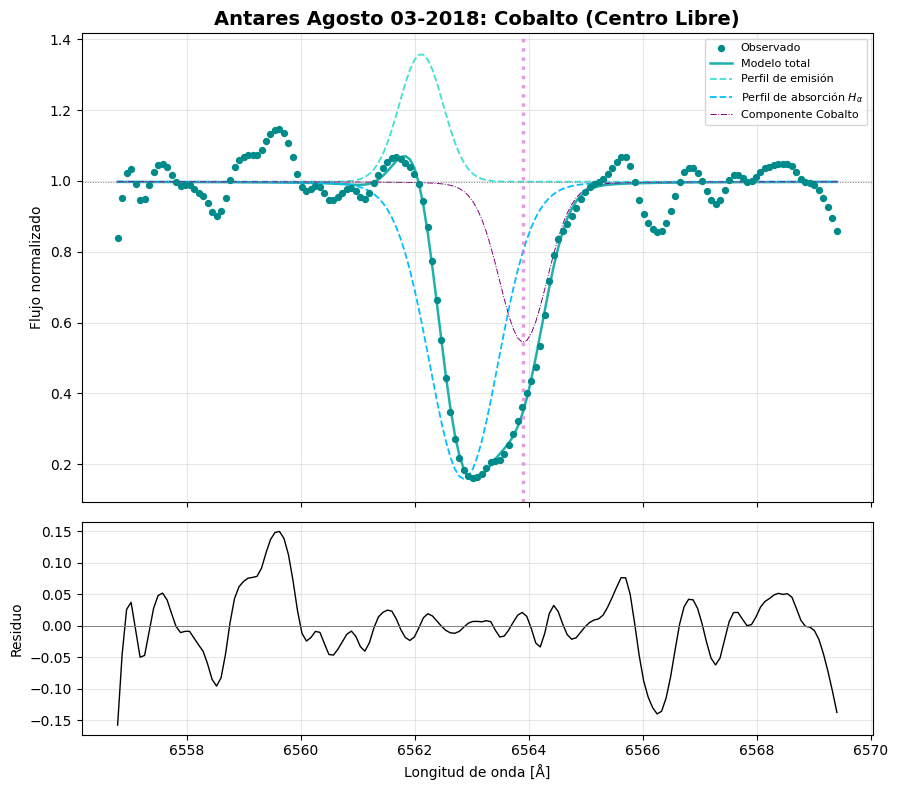

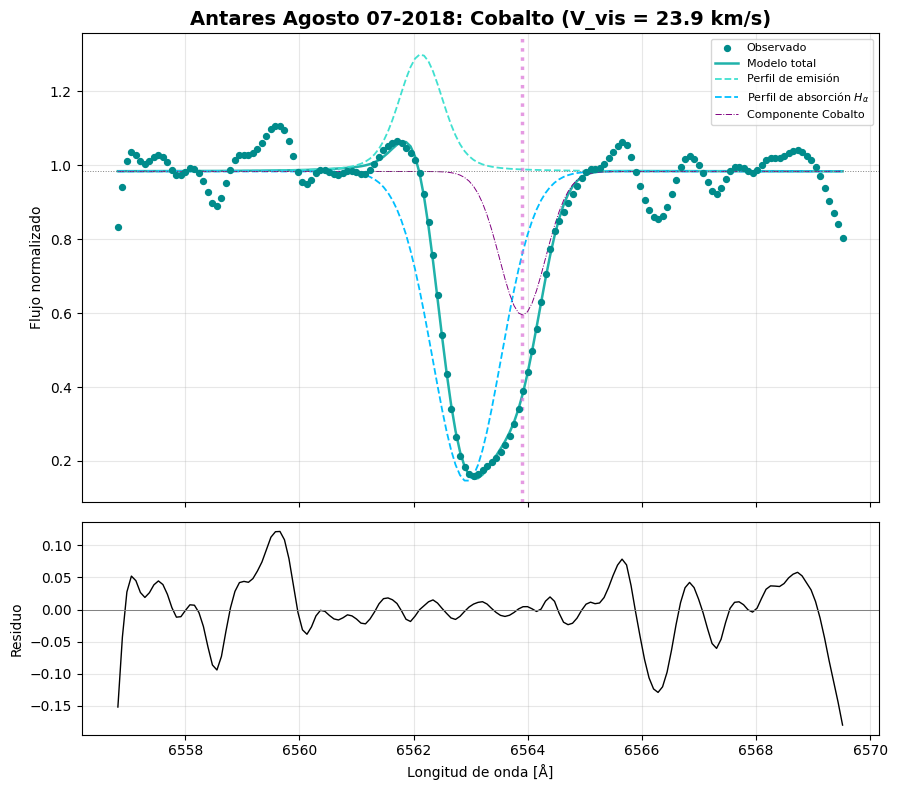

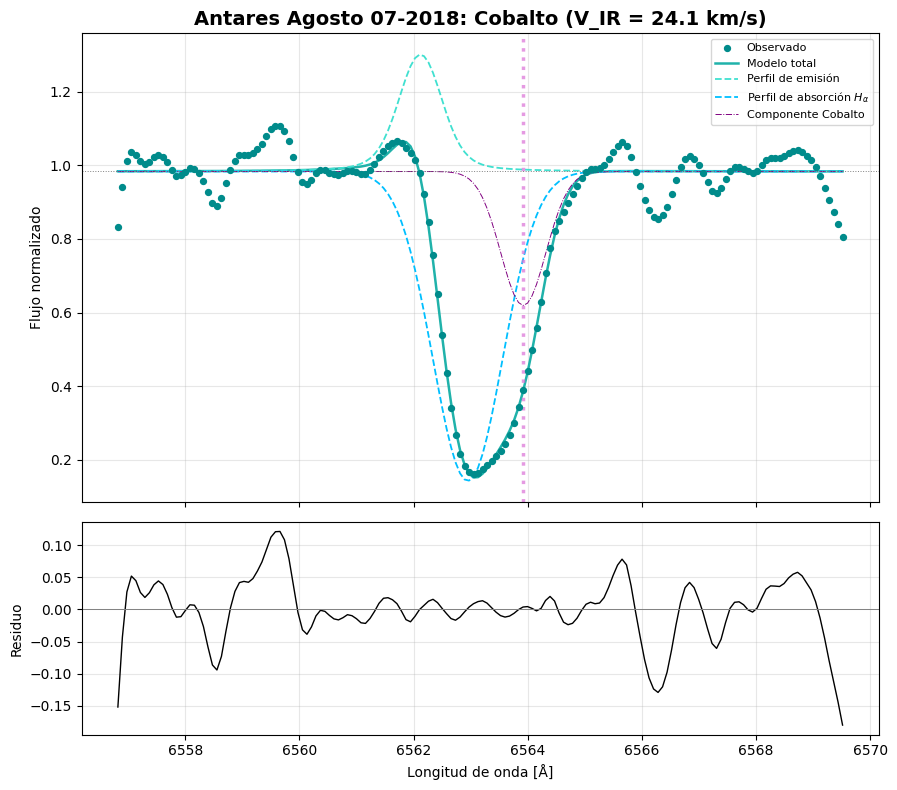

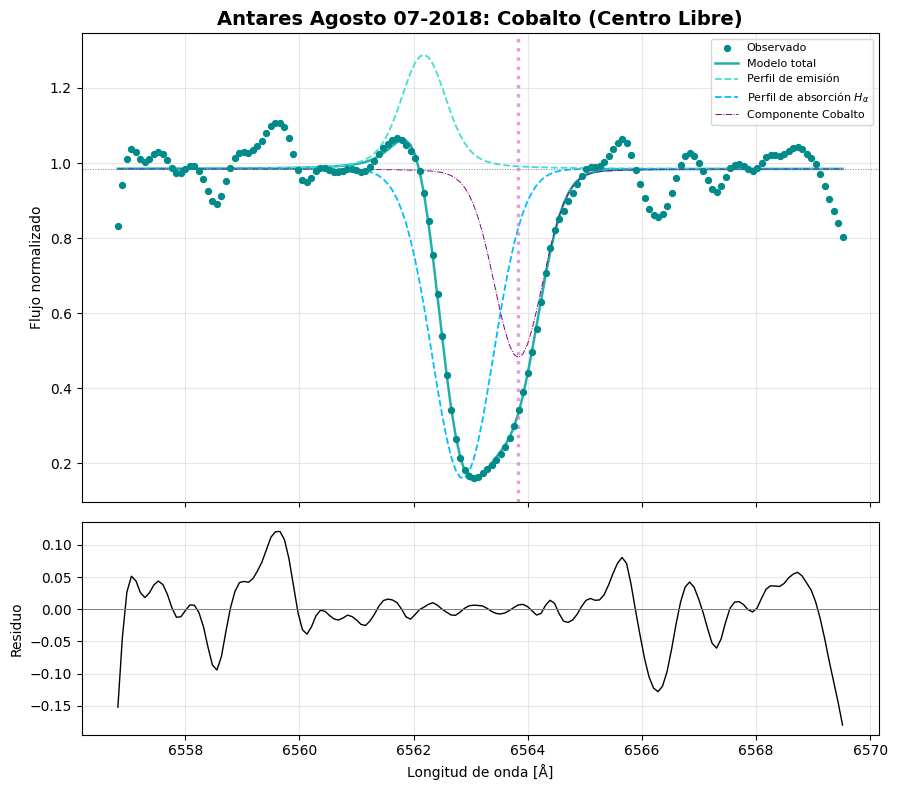

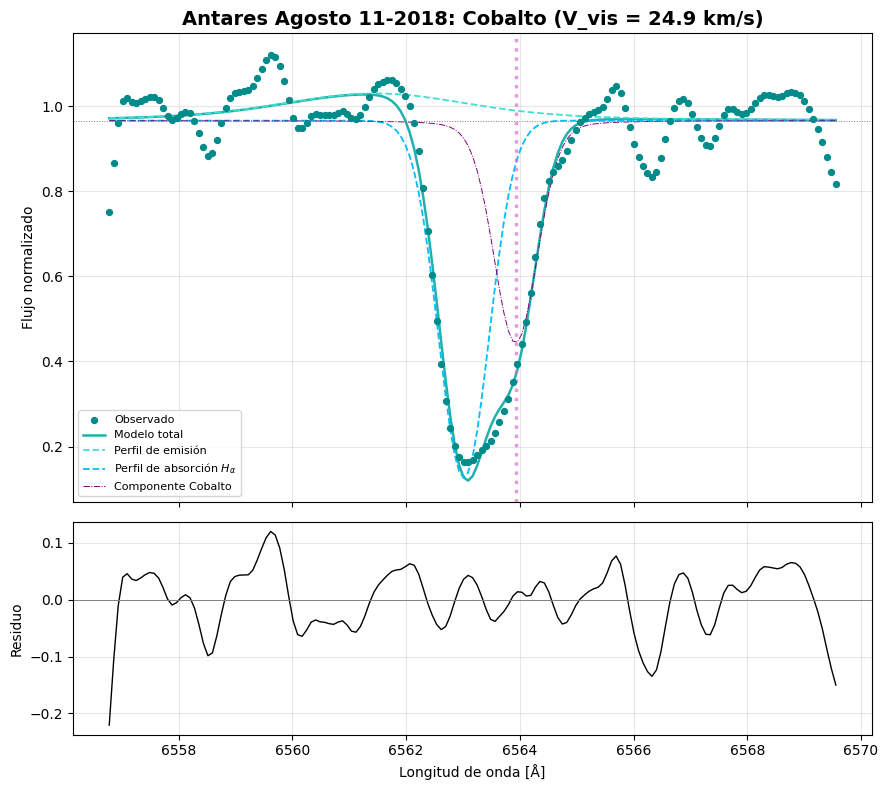

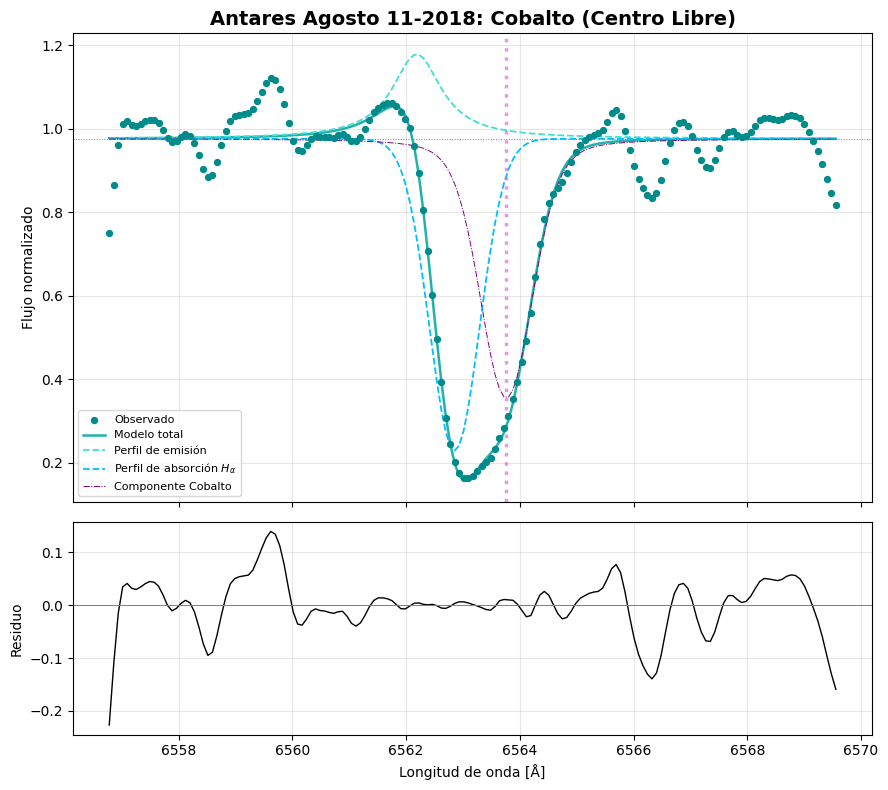

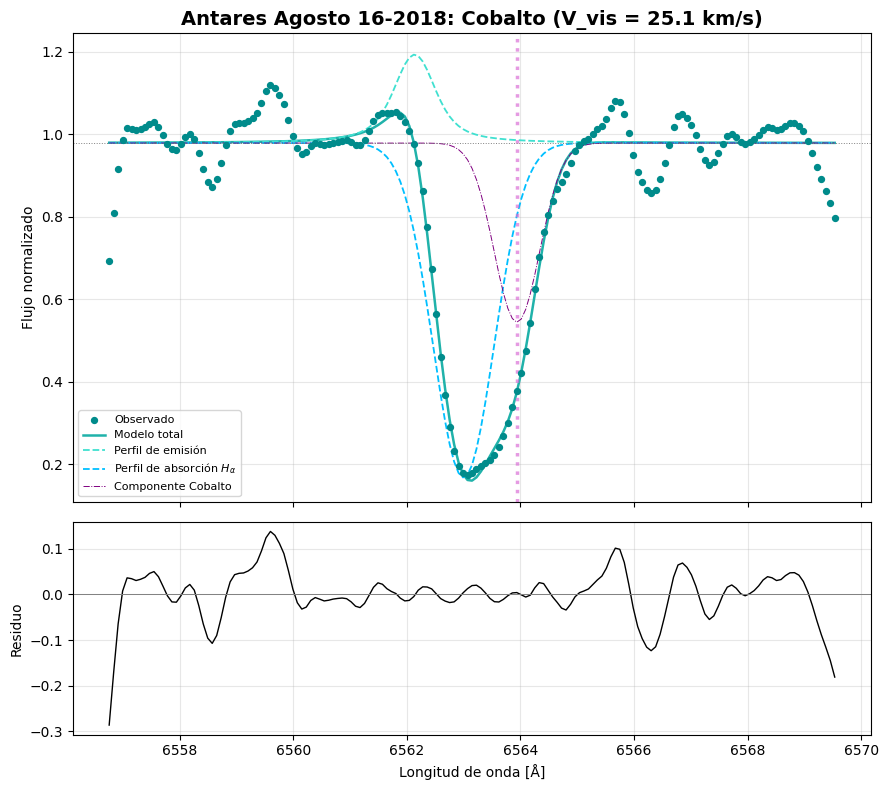

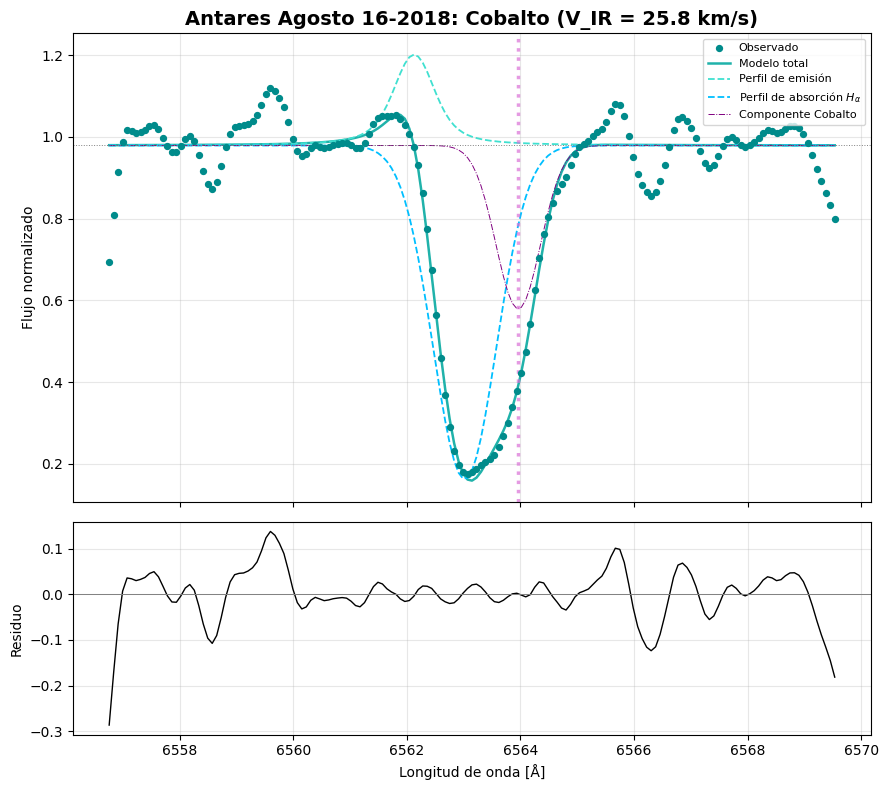

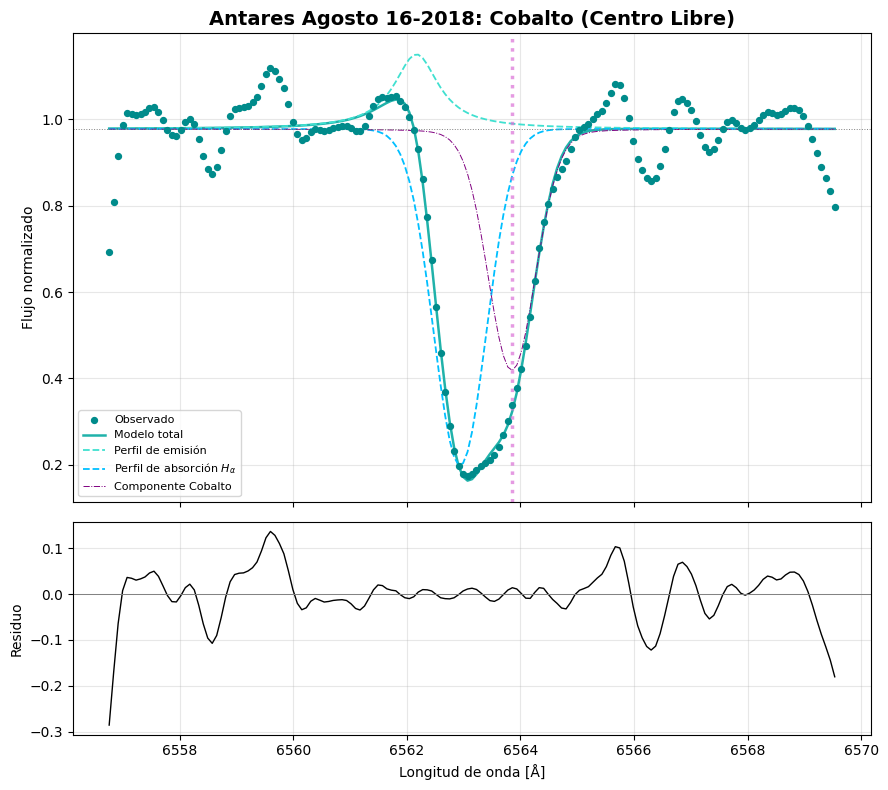

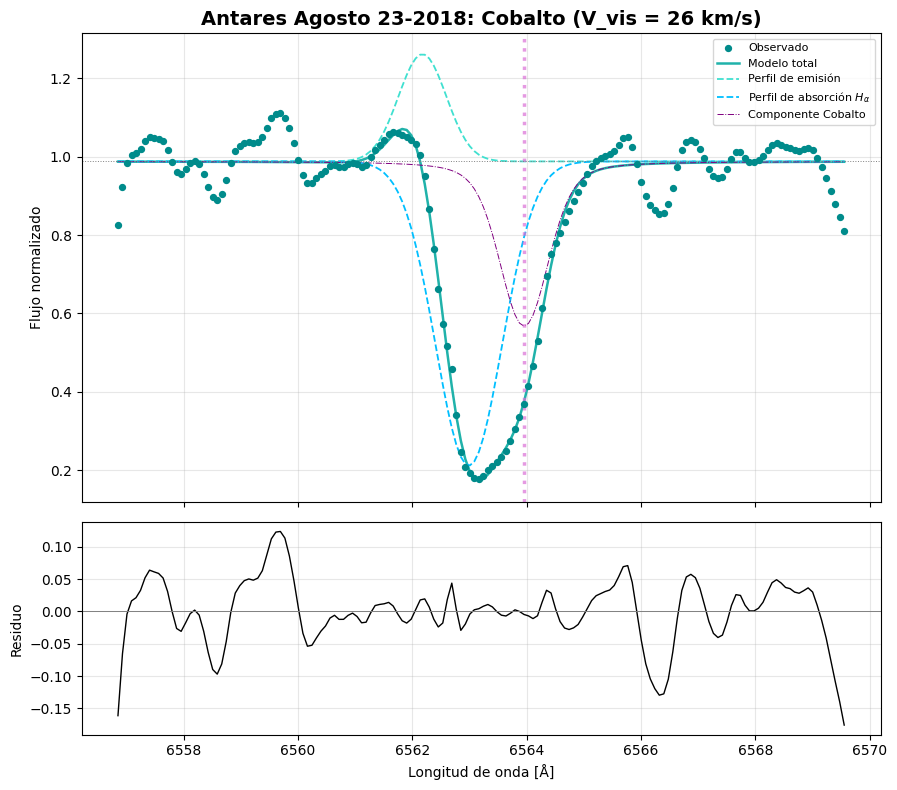

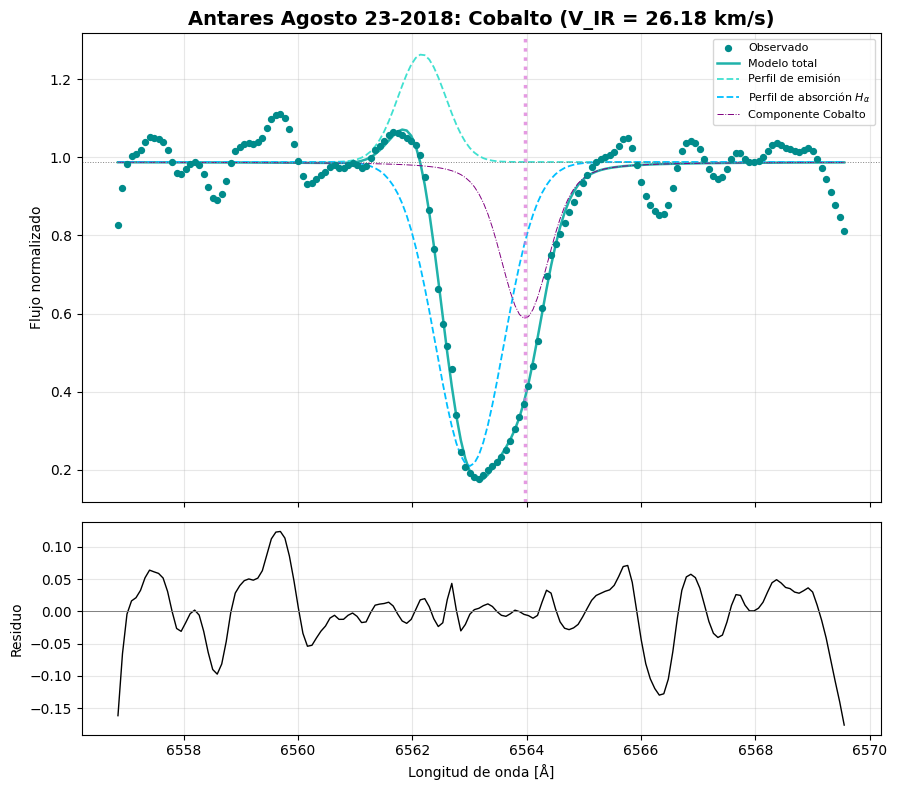

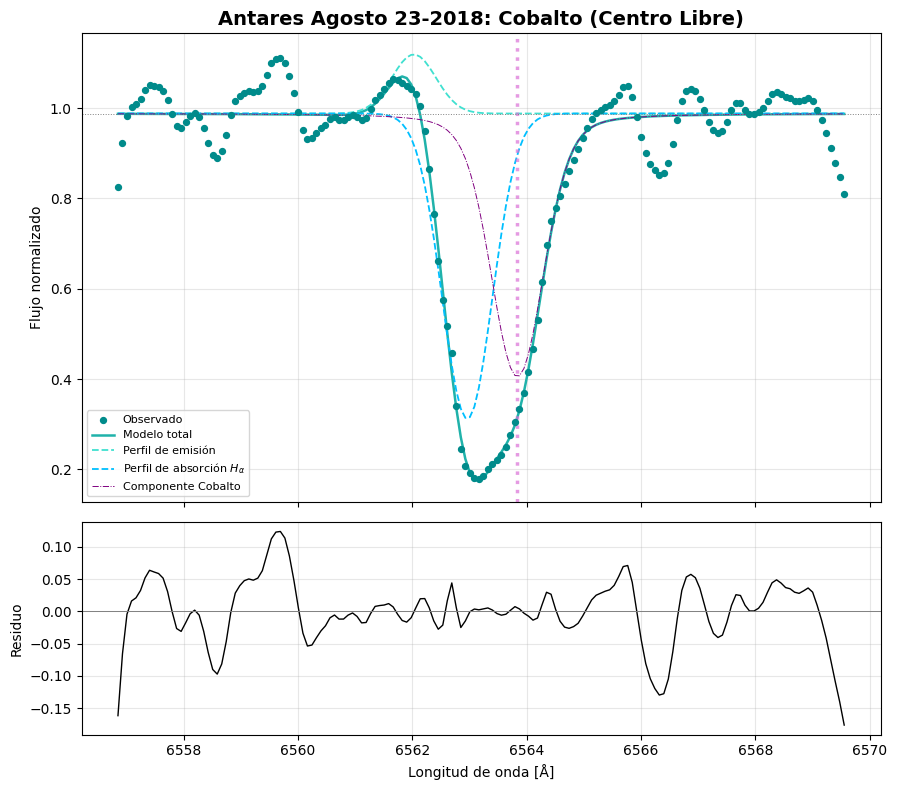

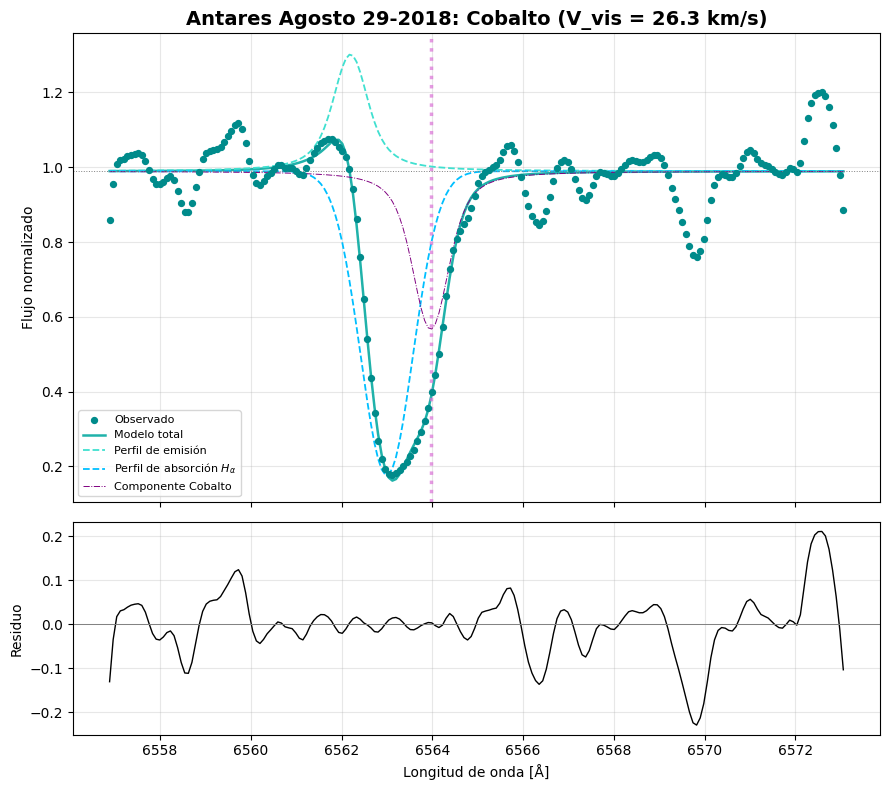

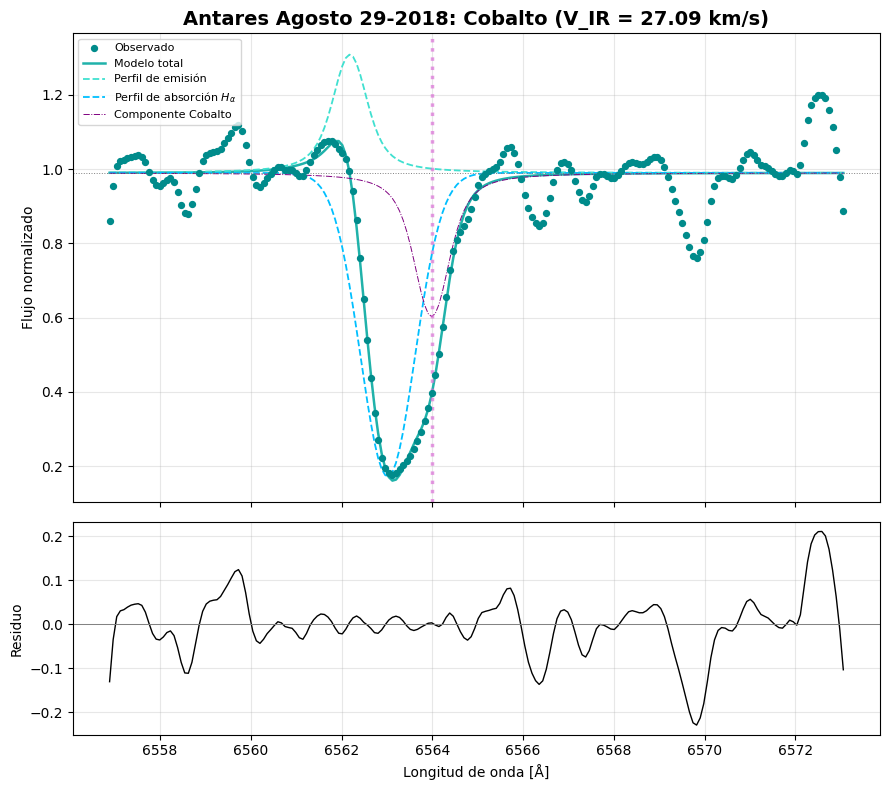

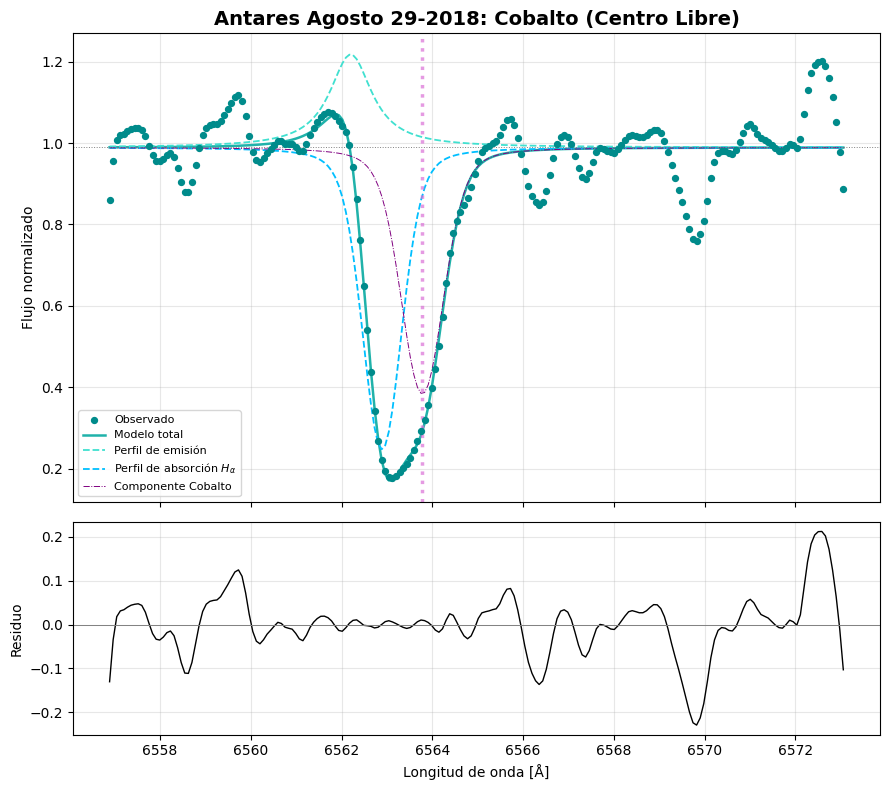

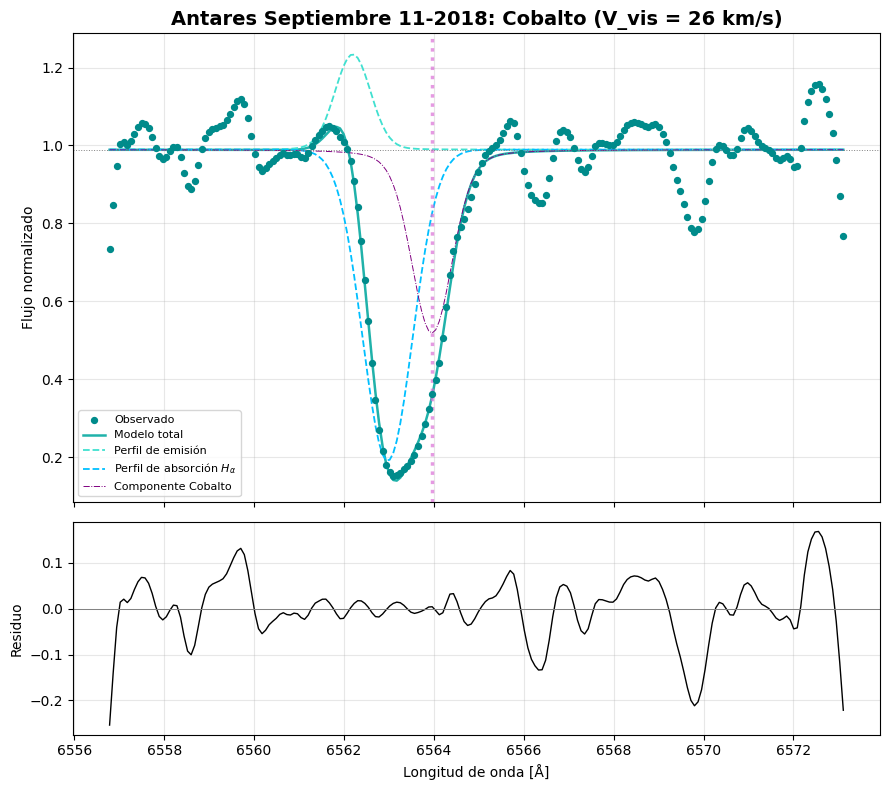

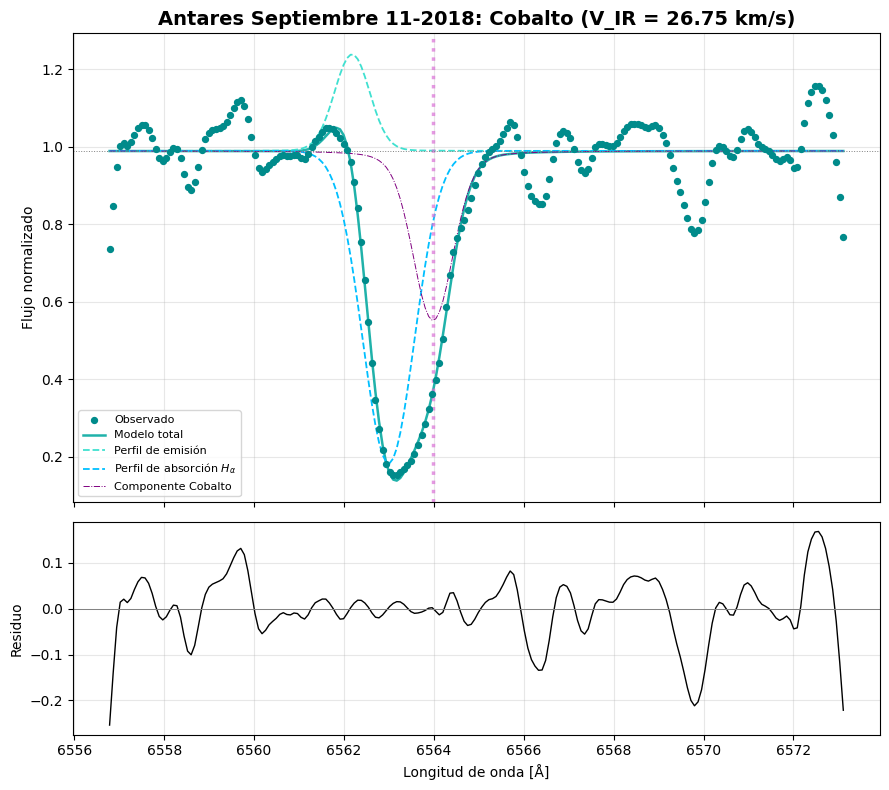

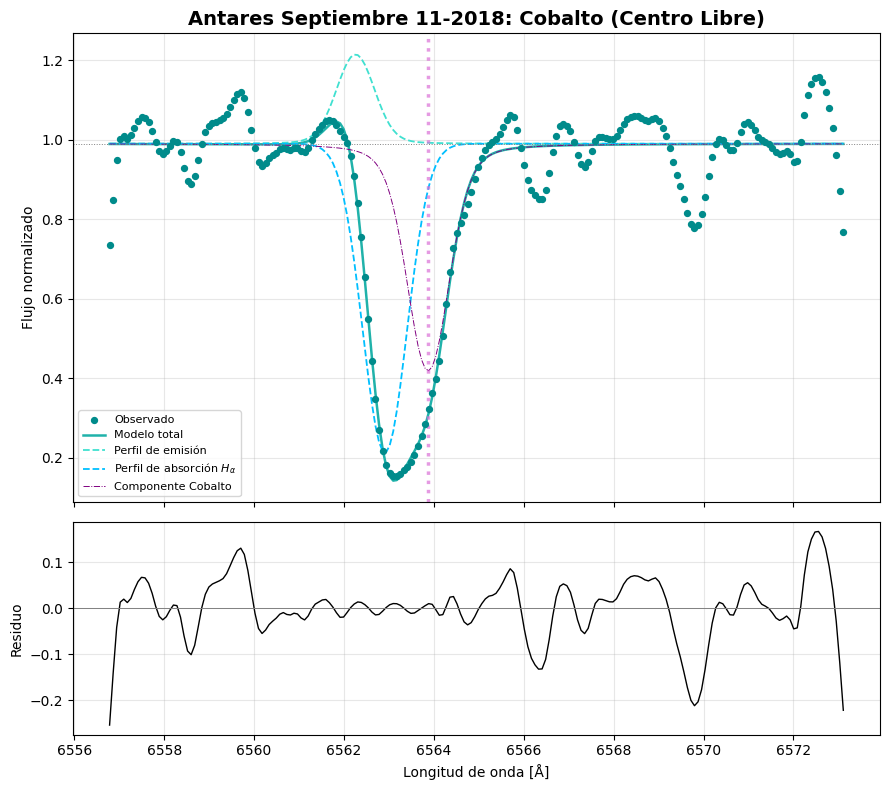

In [21]:
resultados = {}

for nombre, datos in espectros.items():
    meta = metadatos[nombre]
    fecha_str = meta["fecha"]
    

    
    fits_fecha = {}

    # Ajuste velocidad visible

    if meta.get("velocidad_visible") is not None:
        v_vis = meta["velocidad_visible"]
        err_vis = meta.get("incertidumbre_v_visible", 3.0)
        
        lineas_vis = [{
            "nombre": "Cobalto",
            "centro": centro_lab_cobalto,
            "velocidad": v_vis,
            "incertidumbre_v": err_vis,
            "prof_ref": (0.55, 0.63),
            "t_ref": (3500, 4250),
        }]
        
        fits_fecha["visible"] = fit_y_decomposicion(
            datos, meta["centro_aprox"], "Longitud onda", "Flujo normalizado",
            lineas_metalicas=lineas_vis, teff=3660
        )
        
        # Visualización
        visualizacion_con_metalica( fits_fecha["visible"], lineas_vis, f"{fecha_str}_visible",
                                titulo=f"Antares {fecha_str}: Cobalto (V_vis = {v_vis} km/s)"
        )

    # Ajuste velocidad infrarroja (Si existe)

    if meta.get("velocidad_infrarrojo") is not None:
        v_ir = meta["velocidad_infrarrojo"]
        err_ir = meta.get("incertidumbre_v_infrarrojo", 3.0)
        
        lineas_ir = [{
            "nombre": "Cobalto",
            "centro": centro_lab_cobalto,
            "velocidad": v_ir,
            "incertidumbre_v": err_ir,
            "prof_ref": (0.55, 0.63),
            "t_ref": (3500, 4250),
        }]
        
        fits_fecha["infrarrojo"] = fit_y_decomposicion(
            datos, meta["centro_aprox"], "Longitud onda", "Flujo normalizado",
            lineas_metalicas=lineas_ir, teff=3660
        )
        
        # Visualización individual
        visualizacion_con_metalica(
            fits_fecha["infrarrojo"], lineas_ir, f"{fecha_str}_infrarrojo",
            titulo=f"Antares {fecha_str}: Cobalto (V_IR = {v_ir} km/s)"
        )

    # Ajuste de centro libre (Inicia con el promedio de las velocidades de referencia)

    v_ref, _ = velocidad_y_error_combinados(meta)
    
    lineas_libre = [{
        "nombre": "Cobalto",
        "centro": centro_lab_cobalto,
        "centro_libre": True,
        "margen_v_libre": 15.0,
        "velocidad_referencia": v_ref if v_ref is not None else 0.0,
        "prof_ref": (0.55, 0.63),
        "t_ref": (3500, 4250),
    }]
    
    fits_fecha["libre"] = fit_y_decomposicion(
        datos, meta["centro_aprox"], "Longitud onda", "Flujo normalizado",
        lineas_metalicas=lineas_libre, teff=3660
    )
    
    # Visualización
    visualizacion_con_metalica(
        fits_fecha["libre"], lineas_libre, f"{fecha_str}_libre",
        titulo=f"Antares {fecha_str}: Cobalto (Centro Libre)"
    )

    resultados[nombre] = fits_fecha


In [22]:
filas_chi2 = []

for nombre, fits_fecha in resultados.items():
    fecha_etiqueta = metadatos[nombre].get("fecha", nombre)
    
    # Chi del libre
    chi2_libre = fits_fecha["libre"]["fit"].chisqr if "libre" in fits_fecha else None
    
    # Chi del visible
    chi2_vis = fits_fecha["visible"]["fit"].chisqr if "visible" in fits_fecha else None
    
    # Chi del infrarrojo
    chi2_ir = fits_fecha["infrarrojo"]["fit"].chisqr if "infrarrojo" in fits_fecha else "No existe"
    
    filas_chi2.append({
        "χ²": fecha_etiqueta,
        "χ² (Centro Libre)": round(chi2_libre, 4) if isinstance(chi2_libre, (int, float)) else chi2_libre,
        "χ² (Vis)": round(chi2_vis, 4) if isinstance(chi2_vis, (int, float)) else chi2_vis,
        "χ² (IR)": round(chi2_ir, 4) if isinstance(chi2_ir, (int, float)) else chi2_ir
    })

tabla_chi2 = pd.DataFrame(filas_chi2)

display(tabla_chi2)

,χ²,χ² (Centro Libre),χ² (Vis),χ² (IR)
0,Julio 24-2018,0.7420,0.7897,0.742
1,Julio 27-2018,0.3645,0.3685,No existe
2,Agosto 03-2018,0.4388,0.4388,0.4388
3,Agosto 07-2018,0.3743,0.3751,0.3755
4,Agosto 11-2018,0.4465,0.4823,No existe
5,Agosto 16-2018,0.5046,0.5064,0.5076
6,Agosto 23-2018,0.3995,0.4002,0.4004
7,Agosto 29-2018,0.9483,0.9516,0.9527
8,Septiembre 11-2018,0.9271,0.9280,0.9286


In [23]:
tabla_chi2.to_excel(fr"Parámetros para análisis de Antares\Comparación chi cuadrado espectros del 2018.xlsx", index=False)

In [24]:
h_alpha_natural = 6562.812
cobalto_natural = centro_lab_cobalto

resultados_perfiles_halpha_y_cobalto = []

for fecha, fits_fecha in resultados.items():

    fecha_etiqueta = metadatos[fecha].get("fecha", fecha)

    # Encontrar cuál modelo es el mejor

    mejor_clave = min(fits_fecha.keys(), key=lambda k: fits_fecha[k]["fit"].chisqr)
    res = fits_fecha[mejor_clave]
    
    # Extraer parámetros
    p = res["fit"].params
    comps = res["comps"]
    longitud_onda = res["longitud_onda"]
    continuo = comps["cont_"]
    
    ## 1. PERFIL DE EMISIÓN AZUL

    c_em = p["em_azul_center"].value
    fwhm_em = p["em_azul_fwhm"].value
    amp_em = p["em_azul_height"].value 

    # Efecto Doppler (Corrimiento)

    z_em = (c_em - h_alpha_natural) / h_alpha_natural
    v_em = z_em * c_kms_s

    # Ancho equivalente de emisión
    
    perfil_em_puro = comps["em_azul_"]
    ew_em = np.trapezoid(perfil_em_puro / continuo, longitud_onda)
    
    resultados_perfiles_halpha_y_cobalto.append({
        "Época": fecha_etiqueta,
        "Ajuste Seleccionado": mejor_clave,
        "Componente": "Emisión Azul Hα",
        "Centro [Å]": round(c_em, 3),
        "z": round(z_em, 6),
        "Velocidad [km/s]": round(v_em, 4),
        "Profundidad / Altura": round(amp_em, 4),
        "FWHM [Å]": round(fwhm_em, 3),
        "EW [Å]": round(ew_em, 4)
    })
    
    # 2. PERFIL DE ABSORCIÓN H_ALPHA

    c_abs = p["valle_abs_center"].value
    fwhm_abs = p["valle_abs_fwhm"].value
    prof_abs = abs(p["valle_abs_height"].value) 

    # Efecto Doppler (Corrimiento)

    z_abs = (c_abs - h_alpha_natural) / h_alpha_natural
    v_abs = z_abs * c_kms_s

    # Ancho equivalente de emisión
    
    perfil_abs_puro = comps["valle_abs_"]
    ew_abs = np.trapezoid(abs(perfil_abs_puro) / continuo, longitud_onda)
    
    resultados_perfiles_halpha_y_cobalto.append({
        "Época": fecha_etiqueta,
        "Ajuste Seleccionado": mejor_clave,
        "Componente": "Absorción Hα",
        "Centro [Å]": round(c_abs, 3),
        "z": round(z_abs, 6),
        "Velocidad [km/s]": round(v_abs, 4),
        "Profundidad / Altura": round(prof_abs, 4),
        "FWHM [Å]": round(fwhm_abs, 3),
        "EW [Å]": round(ew_abs, 4)
    })

    # 3. LÍNEA DE COBALTO
    c_co = p["Cobalto_center"].value
    fwhm_co = p["Cobalto_fwhm"].value
    prof_co = abs(p["Cobalto_height"].value)

    # Efecto Doppler (Corrimiento)

    z_co = (c_co - cobalto_natural) / cobalto_natural
    v_co = z_co * c_kms_s

    # Ancho equivalente de emisión

    perfil_co_puro = comps["Cobalto_"]
    ew_co = np.trapezoid(abs(perfil_co_puro) / continuo, longitud_onda)

    resultados_perfiles_halpha_y_cobalto.append({
        "Época": fecha_etiqueta,
        "Ajuste Seleccionado": mejor_clave,
        "Componente": "Absorción Cobalto",
        "Centro [Å]": round(c_co, 3),
        "z": round(z_co, 6),
        "Velocidad [km/s]": round(v_co, 4),
        "Profundidad / Altura": round(prof_co, 4),
        "FWHM [Å]": round(fwhm_co, 3),
        "EW [Å]": round(ew_co, 4)
    })

tabla_resultados = pd.DataFrame(resultados_perfiles_halpha_y_cobalto)
display(tabla_resultados)

,Época,Ajuste Seleccionado,Componente,Centro [Å],z,Velocidad [km/s],Profundidad / Altura,FWHM [Å],EW [Å]
0,Julio 24-2018,libre,Emisión Azul Hα,6562.019,-0.000121,-36.2219,0.2750,0.854,0.2514
1,Julio 24-2018,libre,Absorción Hα,6562.839,0.000004,1.2508,0.8031,1.390,1.2500
2,Julio 24-2018,libre,Absorción Cobalto,6563.812,0.000063,18.9484,0.4258,1.014,0.4842
3,Julio 27-2018,libre,Emisión Azul Hα,6562.148,-0.000101,-30.3391,0.1467,1.813,0.3827
4,Julio 27-2018,libre,Absorción Hα,6562.733,-0.000012,-3.5914,0.6654,0.864,0.6200
5,Julio 27-2018,libre,Absorción Cobalto,6563.578,0.000028,8.2697,0.7365,1.222,1.1079
6,Agosto 03-2018,libre,Emisión Azul Hα,6562.110,-0.000107,-32.0812,0.3604,0.905,0.3479
7,Agosto 03-2018,libre,Absorción Hα,6562.857,0.000007,2.0730,0.8391,1.426,1.3018
8,Agosto 03-2018,libre,Absorción Cobalto,6563.900,0.000077,22.9622,0.4535,0.994,0.4978
9,Agosto 07-2018,libre,Emisión Azul Hα,6562.178,-0.000097,-28.9511,0.3044,0.939,0.3463


In [25]:
tabla_resultados.to_excel(fr"Parámetros para análisis de Antares\Resultados perfiles halpha 2018.xlsx", index=False)